# Business Understanding

This project focuses on evaluating whether machine learning models can accurately predict daily temperature variables—average temperature (tavg), maximum temperature (tmax), and minimum temperature (tmin)—across three Nordic countries: Finland, Norway, and Sweden. The analysis considers two forecasting horizons: 1 day ahead and 7 days ahead, enabling an assessment of how prediction accuracy changes with increased temporal distance. The models explored include Linear Regression and Random Forest, both trained on a comprehensive set of temporal features, lagged variables, and rolling statistics derived from historical weather data (2015–2019).

# Questions

1. Can you predict the average temperature, max temperature, and min temperature using machine learning?
2. What is the accuracy of linear regression?
3. What is the accuracy of Random Forest?
4. Are there differences in predictability between the three countries?
5. Accuracy of the model when predicting 1 day ahead vs 7 days ahead?

# Data Understanding

In [30]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "nordics_weather.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "adamwurdits/finland-norway-and-sweden-weather-data-20152019",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 10 records:")
print(df.head(10))

First 10 records:
   country       date  precipitation  snow_depth       tavg       tmax  \
0  Finland   1/1/2015       1.714141  284.545455   1.428571   2.912739   
1  Finland   1/2/2015      10.016667  195.000000   0.553571   2.358599   
2  Finland   1/3/2015       3.956061  284.294118  -1.739286   0.820382   
3  Finland   1/4/2015       0.246193  260.772727  -7.035714  -3.110828   
4  Finland   1/5/2015       0.036364  236.900000 -17.164286  -8.727564   
5  Finland   1/6/2015       1.212626  241.476191 -17.471429 -12.208442   
6  Finland   1/7/2015       3.486432  259.500000  -4.453571  -2.574522   
7  Finland   1/8/2015       4.208500  256.550000  -1.760714  -0.732692   
8  Finland   1/9/2015       1.923116  288.500000  -3.285714  -0.582692   
9  Finland  1/10/2015       1.515152  309.428571  -9.457143  -4.633974   

        tmin  
0  -1.015287  
1  -0.998718  
2  -3.463871  
3  -9.502581  
4 -19.004487  
5 -21.979618  
6 -14.344872  
7  -3.971338  
8  -5.239869  
9 -11.508387  


In [31]:
print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.dtypes)
print("\nBasic stats:")
print(df.describe())

Dataset shape: (5478, 7)

Dataset columns:
country           object
date              object
precipitation    float64
snow_depth       float64
tavg             float64
tmax             float64
tmin             float64
dtype: object

Basic stats:
       precipitation   snow_depth         tavg         tmax         tmin
count    5478.000000  5478.000000  5478.000000  5478.000000  5478.000000
mean        2.373517   127.252197     4.844088     8.415625     0.977423
std         2.794442   165.753504     7.802099     8.523315     7.597392
min         0.000000    -0.168539   -27.951852   -24.197403   -29.639610
25%         0.379808     0.000000    -0.810714     1.718725    -4.079661
50%         1.384036    33.234612     4.282143     7.584506     0.965888
75%         3.410252   215.604972    11.554825    15.883971     7.450520
max        21.947368   682.909091    24.407143    30.561438    17.992891


In [32]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
country          0
date             0
precipitation    0
snow_depth       0
tavg             0
tmax             0
tmin             0
dtype: int64


In [33]:
print("Unique values per column:")
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique values")

Unique values per column:
country: 3 unique values
date: 1826 unique values
precipitation: 5405 unique values
snow_depth: 3485 unique values
tavg: 4645 unique values
tmax: 5460 unique values
tmin: 5452 unique values


In [34]:
print("Duplicates in dataset:", df.duplicated().sum())

Duplicates in dataset: 0


# Data Preparation

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_cols = ['tavg', 'tmax', 'tmin']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['date', 'country']).reset_index(drop=True)
df = df.dropna(subset=target_cols)

df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

LAG_DAYS = 7
for col in target_cols:
    for lag in range(1, LAG_DAYS + 1):
        df[f'{col}_lag_{lag}'] = df.groupby('country')[col].shift(lag)

for col in target_cols:
    df[f'{col}_roll7'] = df.groupby('country')[col].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
    df[f'{col}_roll14'] = df.groupby('country')[col].shift(1).rolling(14).mean().reset_index(level=0, drop=True)

for col in target_cols:
    df[f'{col}_target_1d'] = df.groupby('country')[col].shift(-1)
    df[f'{col}_target_7d'] = df.groupby('country')[col].shift(-7)

df = df.dropna().reset_index(drop=True)

feature_cols = (
    ['country_encoded', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']
    + [f'{col}_lag_{lag}' for col in target_cols for lag in range(1, LAG_DAYS + 1)]
    + [f'{col}_roll7' for col in target_cols]
    + [f'{col}_roll14' for col in target_cols]
)

X = df[feature_cols]
y_1d = df[[f'{col}_target_1d' for col in target_cols]]
y_7d = df[[f'{col}_target_7d' for col in target_cols]]

X_train, X_test, y_train_1d, y_test_1d, y_train_7d, y_test_7d = train_test_split(
    X, y_1d, y_7d, test_size=0.2, shuffle=False
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")


Train: 4348, Test: 1088


# Modeling

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_1d = LinearRegression().fit(X_train, y_train_1d)
lr_7d = LinearRegression().fit(X_train, y_train_7d)
lr_pred_1d = lr_1d.predict(X_test)
lr_pred_7d = lr_7d.predict(X_test)

print("Linear Regression — 1 day ahead")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_1d.iloc[:, i], lr_pred_1d[:, i])
    r2 = r2_score(y_test_1d.iloc[:, i], lr_pred_1d[:, i])
    print(f"  {col}: MAE = {mae:.2f}°C, R² = {r2:.4f}")

print("\nLinear Regression — 7 days ahead")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_7d.iloc[:, i], lr_pred_7d[:, i])
    r2 = r2_score(y_test_7d.iloc[:, i], lr_pred_7d[:, i])
    print(f"  {col}: MAE = {mae:.2f}°C, R² = {r2:.4f}")


Linear Regression — 1 day ahead
  tavg: MAE = 1.90°C, R² = 0.8977
  tmax: MAE = 1.93°C, R² = 0.9160
  tmin: MAE = 2.01°C, R² = 0.8746

Linear Regression — 7 days ahead
  tavg: MAE = 2.74°C, R² = 0.8048
  tmax: MAE = 2.94°C, R² = 0.8201
  tmin: MAE = 2.88°C, R² = 0.7703


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_1d = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train_1d)
rf_7d = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train_7d)
rf_pred_1d = rf_1d.predict(X_test)
rf_pred_7d = rf_7d.predict(X_test)

print("Random Forest — 1 day ahead")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_1d.iloc[:, i], rf_pred_1d[:, i])
    r2 = r2_score(y_test_1d.iloc[:, i], rf_pred_1d[:, i])
    print(f"  {col}: MAE = {mae:.2f}°C, R² = {r2:.4f}")

print("\nRandom Forest — 7 days ahead")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_7d.iloc[:, i], rf_pred_7d[:, i])
    r2 = r2_score(y_test_7d.iloc[:, i], rf_pred_7d[:, i])
    print(f"  {col}: MAE = {mae:.2f}°C, R² = {r2:.4f}")


Random Forest — 1 day ahead
  tavg: MAE = 2.03°C, R² = 0.8851
  tmax: MAE = 2.06°C, R² = 0.9041
  tmin: MAE = 2.13°C, R² = 0.8654

Random Forest — 7 days ahead
  tavg: MAE = 3.18°C, R² = 0.7450
  tmax: MAE = 3.35°C, R² = 0.7662
  tmin: MAE = 3.27°C, R² = 0.7036


# Evaluation

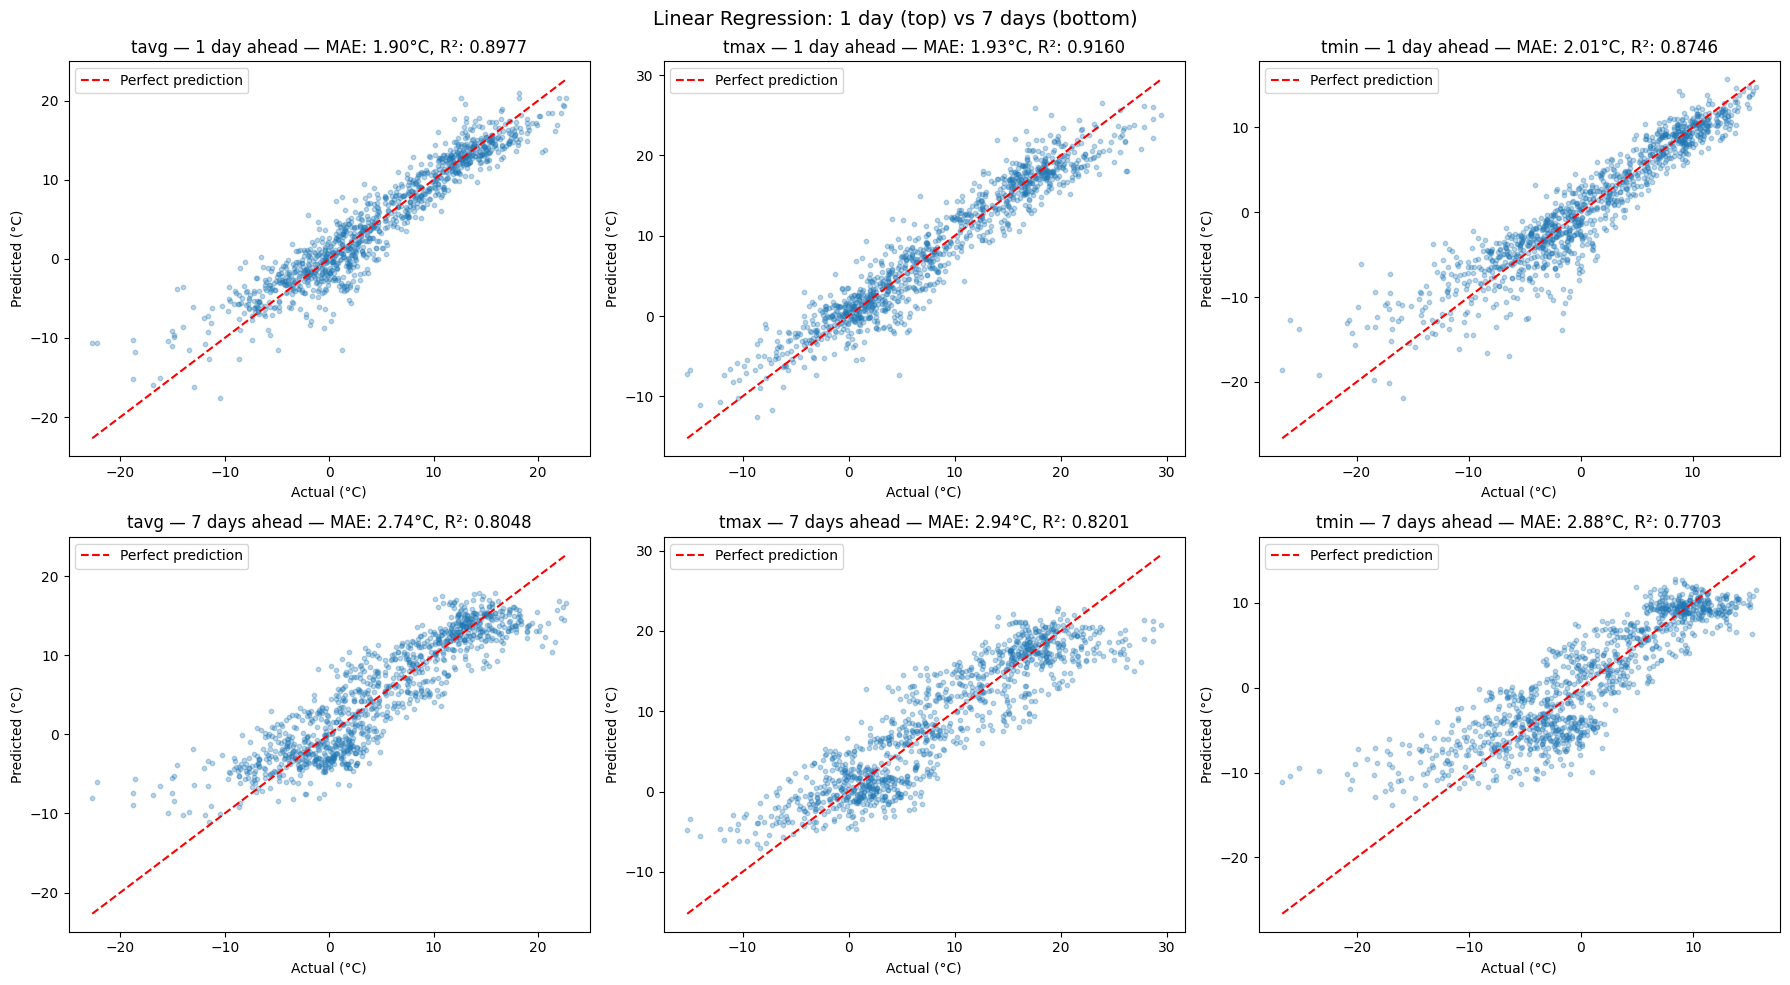

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(target_cols):
    for row, (pred, y_true, label) in enumerate([
        (lr_pred_1d, y_test_1d, '1 day ahead'),
        (lr_pred_7d, y_test_7d, '7 days ahead')
    ]):
        actual = y_true.iloc[:, i].values
        predicted = pred[:, i]
        axes[row][i].scatter(actual, predicted, alpha=0.3, s=10)
        min_val = min(actual.min(), predicted.min())
        max_val = max(actual.max(), predicted.max())
        axes[row][i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
        mae = mean_absolute_error(actual, predicted)
        r2 = r2_score(actual, predicted)
        axes[row][i].set_title(f'{col} — {label} — MAE: {mae:.2f}°C, R²: {r2:.4f}')
        axes[row][i].set_xlabel('Actual (°C)')
        axes[row][i].set_ylabel('Predicted (°C)')
        axes[row][i].legend()

plt.suptitle('Linear Regression: 1 day (top) vs 7 days (bottom)', fontsize=14)
plt.tight_layout()
plt.show()


Linear Regression per country — 1 day ahead
Country    |  tavg MAE   tavg R² |  tmax MAE   tmax R² |  tmin MAE   tmin R²
-------------------------------------------------------------------------------------
Finland    |     2.45°   0.8757 |     2.22°   0.9099 |     2.50°   0.8495 |
Norway     |     1.42°   0.9270 |     1.59°   0.9199 |     1.49°   0.9120 |
Sweden     |     1.84°   0.9016 |     1.98°   0.9189 |     2.04°   0.8780 |

Linear Regression per country — 7 days ahead
Country    |  tavg MAE   tavg R² |  tmax MAE   tmax R² |  tmin MAE   tmin R²
-------------------------------------------------------------------------------------
Finland    |     3.35°   0.7823 |     3.23°   0.8217 |     3.37°   0.7529 |
Norway     |     2.22°   0.8285 |     2.54°   0.8107 |     2.33°   0.7917 |
Sweden     |     2.65°   0.8081 |     3.04°   0.8210 |     2.95°   0.7710 |



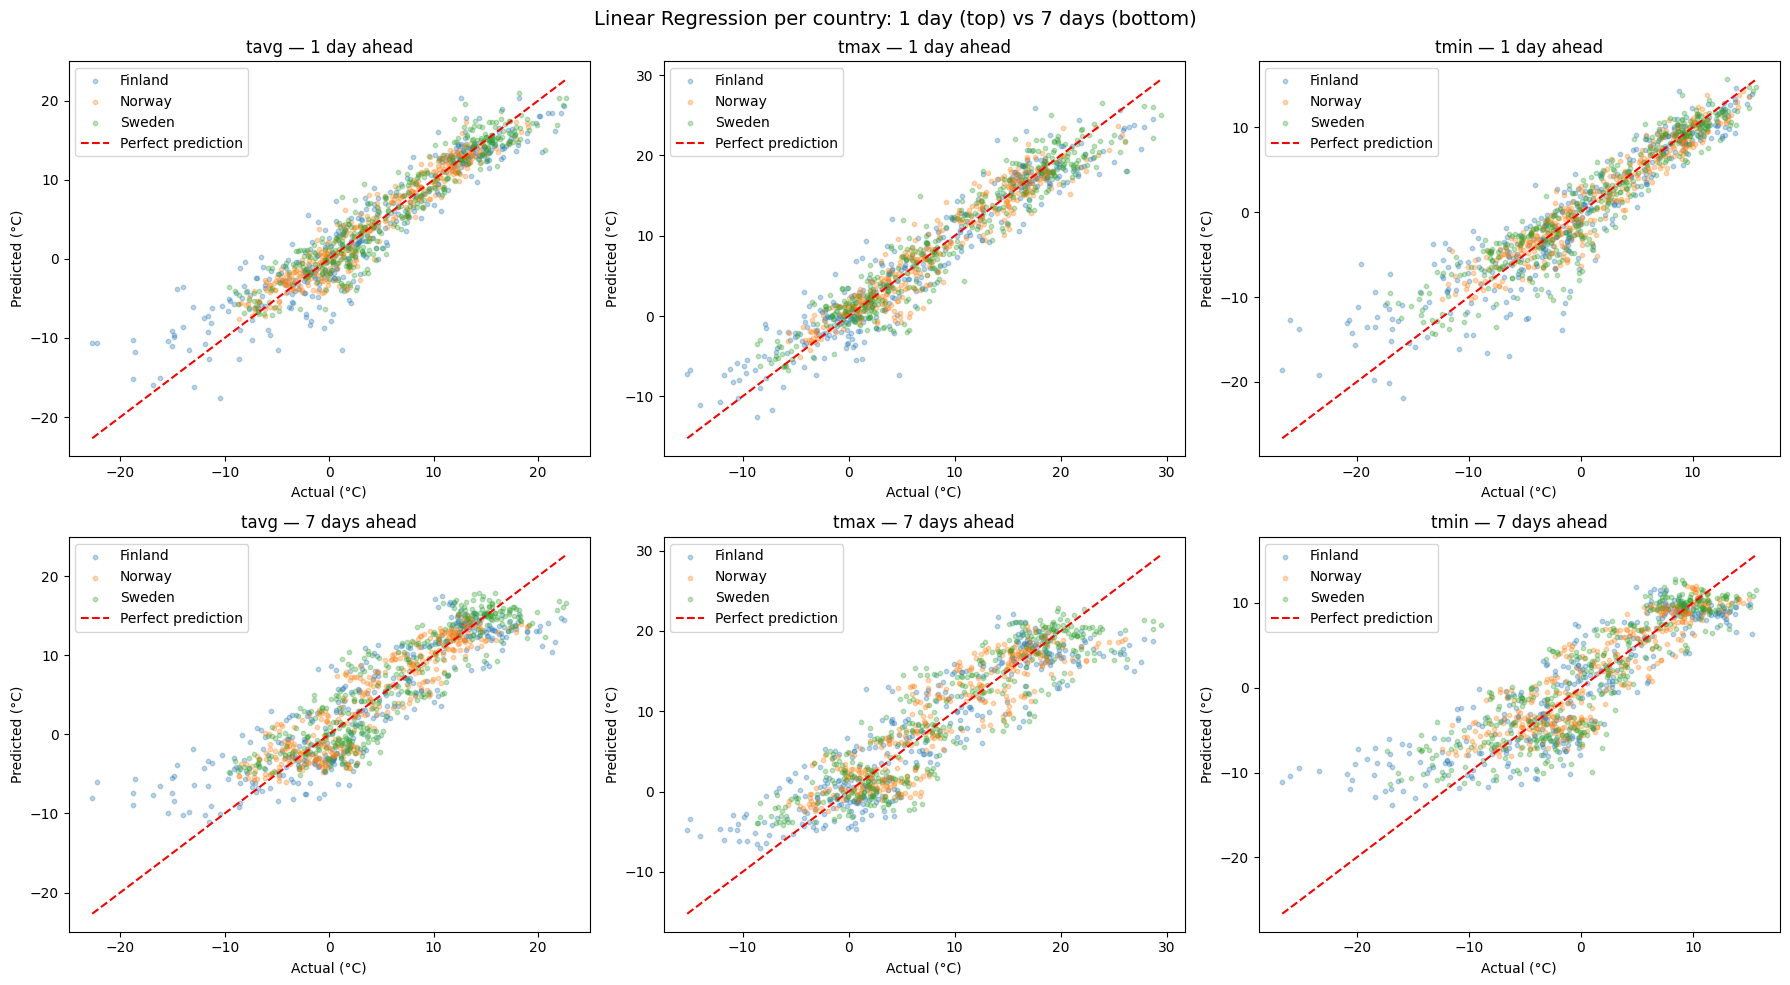

In [39]:
countries = le_country.classes_
test_countries = df.loc[y_test_1d.index, 'country_encoded'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (pred, y_true, label) in enumerate([
    (lr_pred_1d, y_test_1d, '1 day ahead'),
    (lr_pred_7d, y_test_7d, '7 days ahead')
]):
    print(f"Linear Regression per country — {label}")
    print(f"{'Country':<10} | {'tavg MAE':>9} {'tavg R²':>9} | {'tmax MAE':>9} {'tmax R²':>9} | {'tmin MAE':>9} {'tmin R²':>9}")
    print("-" * 85)
    for c_idx, country in enumerate(countries):
        mask = test_countries == c_idx
        row_str = f"{country:<10} |"
        for i, col in enumerate(target_cols):
            mae = mean_absolute_error(y_true.iloc[mask, i], pred[mask, i])
            r2 = r2_score(y_true.iloc[mask, i], pred[mask, i])
            row_str += f" {mae:>8.2f}° {r2:>8.4f} |"
            axes[row][i].scatter(y_true.iloc[mask, i], pred[mask, i], alpha=0.3, s=10, label=country)
        print(row_str)
    print()

    for i, col in enumerate(target_cols):
        min_val = min(y_true.iloc[:, i].min(), pred[:, i].min())
        max_val = max(y_true.iloc[:, i].max(), pred[:, i].max())
        axes[row][i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
        axes[row][i].set_title(f'{col} — {label}')
        axes[row][i].set_xlabel('Actual (°C)')
        axes[row][i].set_ylabel('Predicted (°C)')
        axes[row][i].legend()

plt.suptitle('Linear Regression per country: 1 day (top) vs 7 days (bottom)', fontsize=14)
plt.tight_layout()
plt.show()


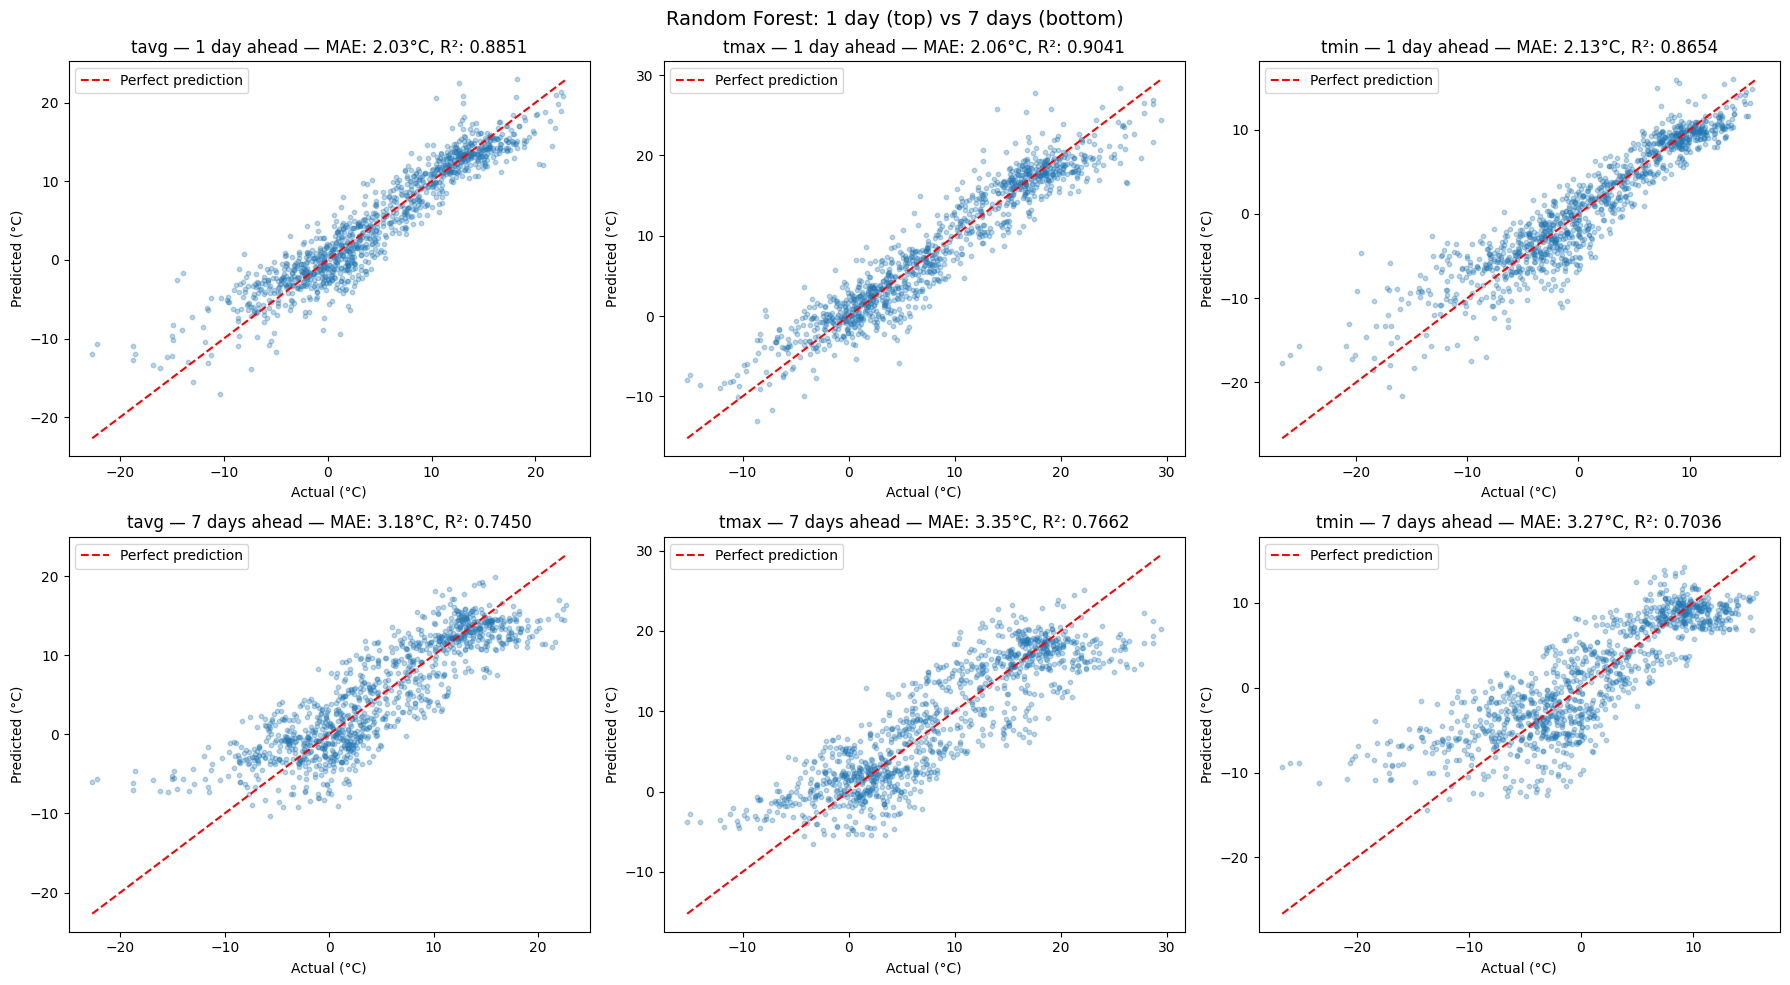

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(target_cols):
    for row, (pred, y_true, label) in enumerate([
        (rf_pred_1d, y_test_1d, '1 day ahead'),
        (rf_pred_7d, y_test_7d, '7 days ahead')
    ]):
        actual = y_true.iloc[:, i].values
        predicted = pred[:, i]
        axes[row][i].scatter(actual, predicted, alpha=0.3, s=10)
        min_val = min(actual.min(), predicted.min())
        max_val = max(actual.max(), predicted.max())
        axes[row][i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
        mae = mean_absolute_error(actual, predicted)
        r2 = r2_score(actual, predicted)
        axes[row][i].set_title(f'{col} — {label} — MAE: {mae:.2f}°C, R²: {r2:.4f}')
        axes[row][i].set_xlabel('Actual (°C)')
        axes[row][i].set_ylabel('Predicted (°C)')
        axes[row][i].legend()

plt.suptitle('Random Forest: 1 day (top) vs 7 days (bottom)', fontsize=14)
plt.tight_layout()
plt.show()


Random Forest per country — 1 day ahead
Country    |  tavg MAE   tavg R² |  tmax MAE   tmax R² |  tmin MAE   tmin R²
-------------------------------------------------------------------------------------
Finland    |     2.59°   0.8645 |     2.38°   0.8969 |     2.62°   0.8440 |
Norway     |     1.54°   0.9123 |     1.65°   0.9117 |     1.54°   0.9079 |
Sweden     |     1.95°   0.8877 |     2.15°   0.9054 |     2.22°   0.8600 |

Random Forest per country — 7 days ahead
Country    |  tavg MAE   tavg R² |  tmax MAE   tmax R² |  tmin MAE   tmin R²
-------------------------------------------------------------------------------------
Finland    |     3.80°   0.7305 |     3.68°   0.7722 |     3.78°   0.6956 |
Norway     |     2.70°   0.7453 |     2.91°   0.7480 |     2.68°   0.7157 |
Sweden     |     3.03°   0.7507 |     3.47°   0.7668 |     3.35°   0.6963 |



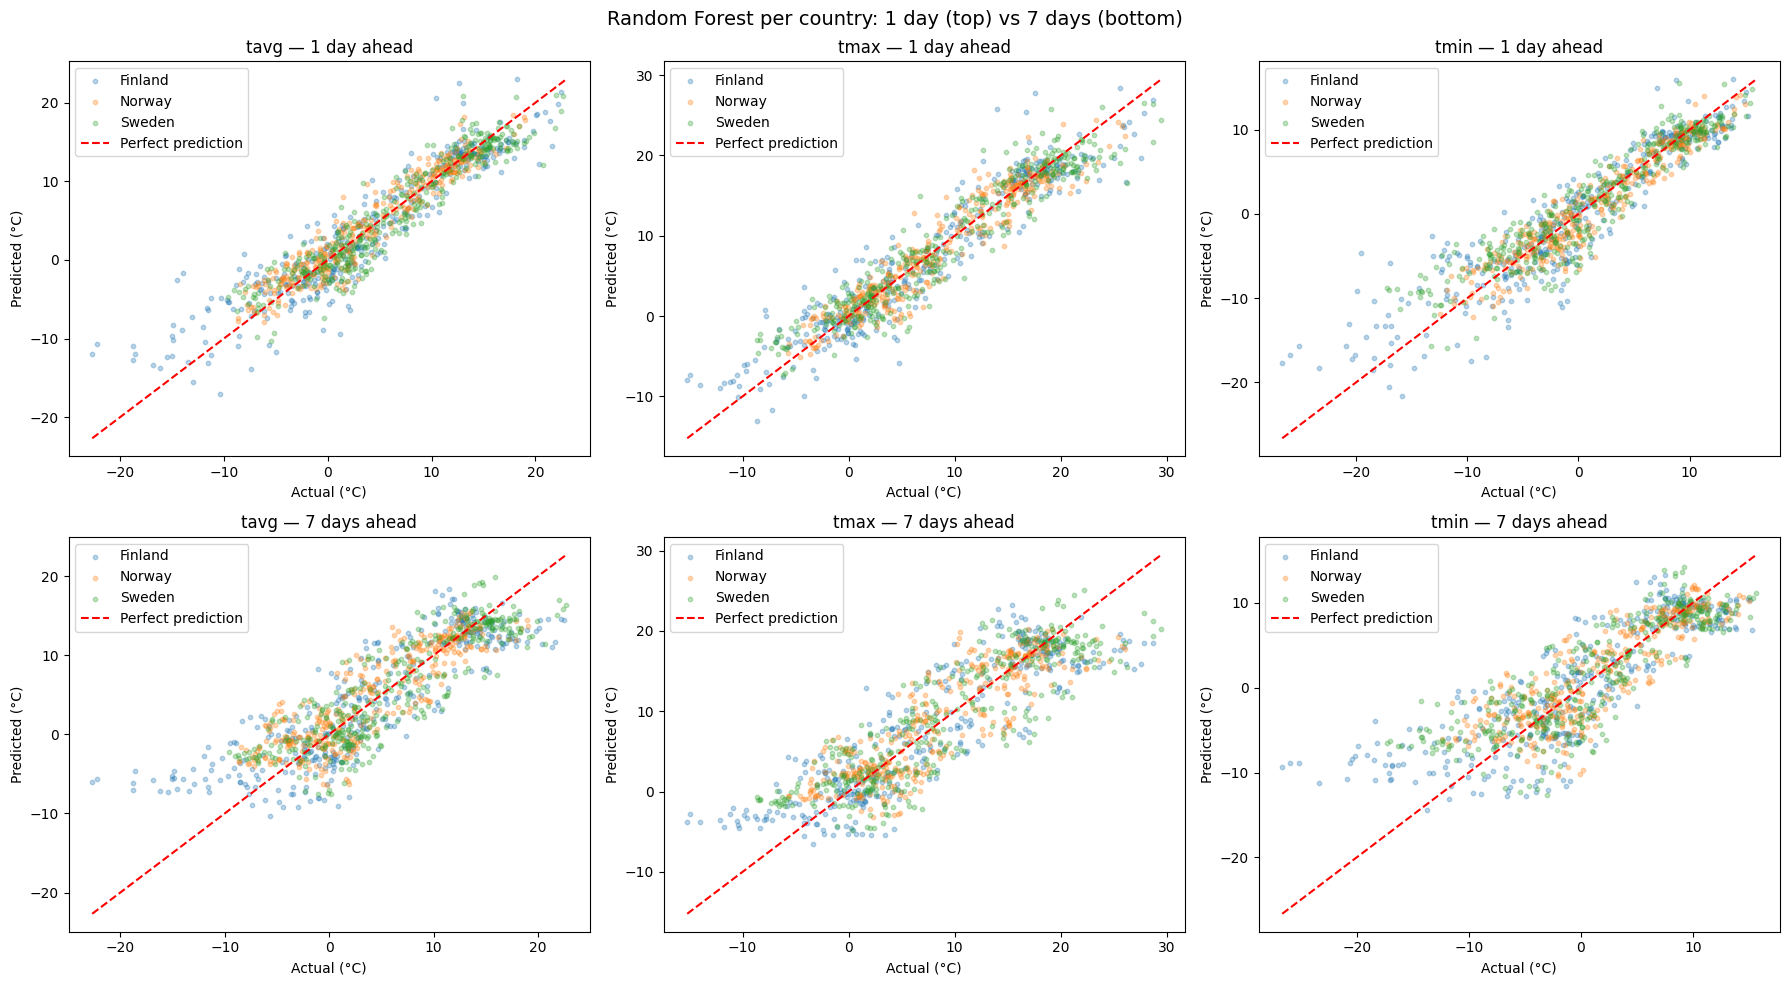

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (pred, y_true, label) in enumerate([
    (rf_pred_1d, y_test_1d, '1 day ahead'),
    (rf_pred_7d, y_test_7d, '7 days ahead')
]):
    print(f"Random Forest per country — {label}")
    print(f"{'Country':<10} | {'tavg MAE':>9} {'tavg R²':>9} | {'tmax MAE':>9} {'tmax R²':>9} | {'tmin MAE':>9} {'tmin R²':>9}")
    print("-" * 85)
    for c_idx, country in enumerate(countries):
        mask = test_countries == c_idx
        row_str = f"{country:<10} |"
        for i, col in enumerate(target_cols):
            mae = mean_absolute_error(y_true.iloc[mask, i], pred[mask, i])
            r2 = r2_score(y_true.iloc[mask, i], pred[mask, i])
            row_str += f" {mae:>8.2f}° {r2:>8.4f} |"
            axes[row][i].scatter(y_true.iloc[mask, i], pred[mask, i], alpha=0.3, s=10, label=country)
        print(row_str)
    print()

    for i, col in enumerate(target_cols):
        min_val = min(y_true.iloc[:, i].min(), pred[:, i].min())
        max_val = max(y_true.iloc[:, i].max(), pred[:, i].max())
        axes[row][i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
        axes[row][i].set_title(f'{col} — {label}')
        axes[row][i].set_xlabel('Actual (°C)')
        axes[row][i].set_ylabel('Predicted (°C)')
        axes[row][i].legend()

plt.suptitle('Random Forest per country: 1 day (top) vs 7 days (bottom)', fontsize=14)
plt.tight_layout()
plt.show()


# Deployment

1. Can you predict the average temperature, max temperature, and min temperature using machine learning?
-Yes.
Both Linear Regression and Random Forest can successfully predict average (tavg), maximum (tmax), and minimum (tmin) temperatures using  historical weather data enriched with time‑based features and lagged values.
The achieved error levels (MAE around 1.9–2.1°C for 1‑day forecasts, and 2.7–3.3°C for 7‑day forecasts) show that the models are able to capture seasonal and temporal patterns well enough for practical short‑ and medium‑term forecasting.

   
2. What is the accuracy of linear regression?


Linear Regression — 1 day ahead
tavg: MAE = 1.90°C, R² = 0.8977
tmax: MAE = 1.93°C, R² = 0.9160
tmin: MAE = 2.01°C, R² = 0.8746

Linear Regression — 7 day ahead
tavg: MAE = 2.74°C, R² = 0.8048
tmax: MAE = 2.94°C, R² = 0.8201
tmin: MAE = 2.88°C, R² = 0.7703

Interpretation:
Linear Regression retains relatively strong predictive power even at a 7‑day horizon, with only moderate increases in error. Its stable performance suggests that temperature dynamics in the dataset are largely linear and heavily driven by cyclical patterns captured by sinusoidal features.


3. What is the accuracy of Random Forest?

Random Forest — 1 day ahead
tavg: MAE = 2.03°C, R² = 0.8851
tmax: MAE = 2.06°C, R² = 0.9041
tmin: MAE = 2.13°C, R² = 0.8654


Random Forest — 7 day ahead
tavg: MAE = 3.18°C, R² = 0.7450
tmax: MAE = 3.35°C, R² = 0.7662
tmin: MAE = 3.27°C, R² = 0.7036

Interpretation:
Random Forest excels at modeling nonlinearities, but in this case, the linear and cyclical components dominate. As a result, Random Forest does not outperform the simpler linear model. Its accuracy also deteriorates more sharply at 7‑day forecasts.


4. Are there differences in predictability between the three countries?
   
-Yes.  Clear differences emerged across the Nordic countries.
Across both models and forecasting horizons:

Norway is consistently the easiest to predict, achieving the highest R² scores.
Sweden performs moderately well, generally falling between Norway and Finland.
Finland is the most challenging country to model, with the lowest predictability scores.

Linear Regression — 1 day ahead

Norway has the highest predictability (R² ≈ 0.92),
Sweden is in the middle,
Finland is the hardest to predict (R² ≈ 0.87).

Linear Regression — 7 days ahead
The pattern remains the same:

Norway remains the most predictable,
Finland the least predictable.

Interpretation:
Norway’s climate is more ocean‑regulated, resulting in smoother temperature trends and higher predictability.
Finland’s more continental climate produces sharper temperature swings, making predictions inherently harder.

 
5. Accuracy of the model when predicting 1 day ahead vs 7 days ahead?

Both models show a substantial decrease in accuracy as the forecasting horizon increases from 1 to 7 days.

Linear Regression
MAE increases by approximately 40–55%.
R² decreases from 0.87–0.92 to 0.77–0.82.


Random Forest
MAE increases by 55–60%.
R² drops more sharply, from 0.86–0.90 to 0.70–0.77.

Interpretation:
Short‑term forecasts (1 day ahead) are highly accurate because yesterday’s weather is a strong predictor of tomorrow’s temperature.
By contrast, 7‑day forecasts contain greater uncertainty due to cumulative variability in atmospheric conditions. Nevertheless, both models retain reasonable medium‑range predictive ability.


Conclusion

Machine learning models can effectively forecast temperature variables across the Nordic region, with strong performance for next‑day predictions and useful, though less precise, results for 7‑day forecasts. Linear Regression performs surprisingly well, outperforming Random Forest in most cases and displaying better stability over longer horizons. Predictability varies significantly by country, with Norway being the most stable and Finland the least predictable. These findings highlight both the strengths of data‑driven weather modeling and the inherent challenges of forecasting several days into the future.